In [19]:
import xscen as xs
import xarray as xr
from xscen import CONFIG
from matplotlib import pyplot as plt
import xclim as xc
import figanos.matplotlib as fg
from datetime import datetime
import cartopy.crs as ccrs
from matplotlib.colors import LogNorm
import numpy as np
import random
import glob
fg.utils.set_mpl_style('ouranos')
xs.load_config("../config/config_general.yml", "../config/config_region.yml", "../config/paths.yml")

# health checks

In [38]:
# print any health checks raised
for f in np.sort(glob.glob(f"{CONFIG['paths']['final']}/checks/NAM-C3/*")):
    print(f.split("/")[-1])
    ds= xr.open_zarr(f)
    for var in ds.data_vars:
        if ds[var].values:
            print(var, ds[var].values)

CMIP6_ScenarioMIP_CSIRO-ARCCSS_ACCESS-CM2_ssp585_r1i1p1f1_global+CaSRv32+NAM-C3_checks.zarr.zip
pr_very_large_precipitation_events True
tasmax_temperature_extremely_high True
tasmin_temperature_extremely_low True
CMIP6_ScenarioMIP_CSIRO_ACCESS-ESM1-5_ssp126_r1i1p1f1_global+CaSRv32+NAM-C3_checks.zarr.zip
tasmin_temperature_extremely_low True
CMIP6_ScenarioMIP_CSIRO_ACCESS-ESM1-5_ssp585_r1i1p1f1_global+CaSRv32+NAM-C3_checks.zarr.zip
tasmax_temperature_extremely_high True
tasmin_temperature_extremely_low True
CMIP6_ScenarioMIP_EC-Earth-Consortium_EC-Earth3-Veg_ssp126_r1i1p1f1_global+CaSRv32+NAM-C3_checks.zarr.zip
tasmin_temperature_extremely_low True
CMIP6_ScenarioMIP_EC-Earth-Consortium_EC-Earth3-Veg_ssp245_r1i1p1f1_global+CaSRv32+NAM-C3_checks.zarr.zip
pr_very_large_precipitation_events True
tasmin_temperature_extremely_low True
CMIP6_ScenarioMIP_EC-Earth-Consortium_EC-Earth3-Veg_ssp585_r1i1p1f1_global+CaSRv32+NAM-C3_checks.zarr.zip
pr_very_large_precipitation_events True
tasmax_tempera

In [55]:
import copy
dict_sim_id = xs.search_data_catalogs(**{'variables_and_freqs': {'tasmax': 'D', 'tasmin': 'D', 'pr': 'D', 'dtr': 'D'},
 'match_hist_and_fut': True,
 'allow_conversion': True,
 'allow_resampling': False,
 #'periods': ['1950', '2300'],
 'restrict_members': {'ordered': 1},
 'other_search_criteria': {'processing_level': 'raw',
  'mip_era': 'CMIP6',
  'experiment': ['ssp534-over']},
 'data_catalogs': ['/project/ctb-frigon/scenario/catalogues/simulation.json']},)
sim_ids= list(dict_sim_id.keys())
sim_ids

2025-12-11 10:58:32 INFO     xscen.extract   Catalog opened: < catalog with 727 dataset(s) from 52527 asset(s)> from 1 files.


INFO:xscen.extract:Catalog opened: < catalog with 727 dataset(s) from 52527 asset(s)> from 1 files.


2025-12-11 10:58:32 INFO     xscen.extract   Dispatching historical dataset to future experiments.


INFO:xscen.extract:Dispatching historical dataset to future experiments.


2025-12-11 10:58:33 INFO     xscen.extract   1686 assets matched the criteria : {'processing_level': 'raw', 'mip_era': 'CMIP6', 'experiment': ['ssp534-over']}.


...

2025-12-11 10:58:34 INFO     xscen.extract   Dataset CMIP6_ScenarioMIP_CanESM5_global_CCCma_ssp534-over has 2 valid members. Restricting as per requested.


INFO:xscen.extract:Dataset CMIP6_ScenarioMIP_CanESM5_global_CCCma_ssp534-over has 2 valid members. Restricting as per requested.


2025-12-11 10:58:34 INFO     xscen.extract   Removing CMIP6_ScenarioMIP_CCCma_CanESM5_ssp534-over_r2i1p1f1_global from the results.


INFO:xscen.extract:Removing CMIP6_ScenarioMIP_CCCma_CanESM5_ssp534-over_r2i1p1f1_global from the results.


['CMIP6_ScenarioMIP_MOHC_UKESM1-0-LL_ssp534-over_r1i1p1f2_global',
 'CMIP6_ScenarioMIP_NCAR_CESM2-WACCM_ssp534-over_r1i1p1f1_global',
 'CMIP6_ScenarioMIP_IPSL_IPSL-CM6A-LR_ssp534-over_r1i1p1f1_global',
 'CMIP6_ScenarioMIP_CCCma_CanESM5_ssp534-over_r1i1p1f1_global',
 'CMIP6_ScenarioMIP_EC-Earth-Consortium_EC-Earth3_ssp534-over_r101i1p1f1_global']

In [46]:
CONFIG['extraction']['simulation']['search_data_catalogs']

{'variables_and_freqs': {'tasmax': 'D', 'tasmin': 'D', 'pr': 'D', 'dtr': 'D'},
 'match_hist_and_fut': True,
 'allow_conversion': True,
 'allow_resampling': False,
 'periods': ['1950', '2300'],
 'restrict_members': {'ordered': 1},
 'other_search_criteria': {'processing_level': 'raw',
  'mip_era': 'CMIP6',
  'experiment': ['ssp126', 'ssp245', 'ssp370', 'ssp585']},
 'data_catalogs': ['/project/ctb-frigon/scenario/catalogues/simulation.json']}

In [52]:
import os
import xscen as xs
import xclim as xc
import copy



args={'variables_and_freqs': {'tasmax': 'D', 'tasmin': 'D', 'pr': 'D', 'dtr': 'D'},
 'match_hist_and_fut': True,
 'allow_conversion': True,
 'allow_resampling': False,
 'periods': ['1950', '2300'],
 'restrict_members': {'ordered': 1},
 'other_search_criteria': {'processing_level': 'raw',
  'mip_era': 'CMIP6',
  'id':'CMIP6_ScenarioMIP_EC-Earth-Consortium_EC-Earth3-Veg_ssp370_r1i1p1f1_global',},
 'data_catalogs': ['/project/ctb-frigon/scenario/catalogues/simulation.json']}
args['other_search_criteria'] = {'id': 'CMIP6_ScenarioMIP_EC-Earth-Consortium_EC-Earth3-Veg_ssp370_r1i1p1f1_global'}
# search cat
cat_sim_id = xs.search_data_catalogs(**args,)

# extract
dc_id = cat_sim_id.popitem()[1]


#FIXME: trick to fix time until xscen13.1, PR661
def pre(ds):
    ds['time']= ds.time.dt.floor('D')
    return ds
ds_sim = xs.extract_dataset(catalog=dc_id,
                            region=CONFIG['custom']['full_region'],
                            preprocess=pre, # FIXME: see above
                            **CONFIG['extraction']['simulation']['extract_dataset'],
                            )['D']

# clean up time
ds_sim['time'] = ds_sim.time.dt.floor('D') 

ds_sim = xs.clean_up(ds_sim, **CONFIG['extraction']['clean_up'])

ds_sim = ds_sim.chunk(CONFIG['chunks']['pre-regrid'])

ds_sim



2025-12-11 10:47:10 INFO     xscen.extract   Catalog opened: < catalog with 727 dataset(s) from 52527 asset(s)> from 1 files.


INFO:xscen.extract:Catalog opened: < catalog with 727 dataset(s) from 52527 asset(s)> from 1 files.


2025-12-11 10:47:10 INFO     xscen.extract   Dispatching historical dataset to future experiments.


INFO:xscen.extract:Dispatching historical dataset to future experiments.


2025-12-11 10:47:11 INFO     xscen.extract   471 assets matched the criteria : {'id': 'CMIP6_ScenarioMIP_EC-Earth-Consortium_EC-Earth3-Veg_ssp370_r1i1p1f1_global'}.


...

DEBUG:xscen.extract:At var dtr, after search cat has ['dtr']


2025-12-11 10:47:11 INFO     xscen.extract   Found 1 with all variables requested and corresponding to the criteria.


INFO:xscen.extract:Found 1 with all variables requested and corresponding to the criteria.
HDF5-DIAG: Error detected in HDF5 (1.14.2) MPI-process 0:
  #000: H5A.c line 679 in H5Aopen_by_name(): unable to synchronously open attribute
    major: Attribute
    minor: Can't open object
  #001: H5A.c line 641 in H5A__open_by_name_api_common(): unable to open attribute: '_QuantizeBitGroomNumberOfSignificantDigits'
    major: Attribute
    minor: Can't open object
  #002: H5A.c line 464 in H5A__open_common(): unable to open attribute: '_QuantizeBitGroomNumberOfSignificantDigits'
    major: Attribute
    minor: Can't open object
  #003: H5VLcallback.c line 1138 in H5VL_attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #004: H5VLcallback.c line 1105 in H5VL__attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #005: H5VLnative_attr.c line 169 in H5VL__native_attr_open(): can't open attribute
    major: 

ESMDataSourceError: Failed to load dataset with key='CMIP6_ScenarioMIP_EC-Earth-Consortium_EC-Earth3-Veg_ssp370_r1i1p1f1_global.global.raw.D'
                 You can use `cat['CMIP6_ScenarioMIP_EC-Earth-Consortium_EC-Earth3-Veg_ssp370_r1i1p1f1_global.global.raw.D'].df` to inspect the assets/files for this key.
                 


  #008: H5Adense.c line 383 in H5A__dense_open(): can't locate attribute in name index
    major: Attribute
    minor: Object not found
HDF5-DIAG: Error detected in HDF5 (1.14.2) MPI-process 0:
  #000: H5A.c line 679 in H5Aopen_by_name(): unable to synchronously open attribute
    major: Attribute
    minor: Can't open object
  #001: H5A.c line 641 in H5A__open_by_name_api_common(): unable to open attribute: '_QuantizeBitGroomNumberOfSignificantDigits'
    major: Attribute
    minor: Can't open object
  #002: H5A.c line 464 in H5A__open_common(): unable to open attribute: '_QuantizeBitGroomNumberOfSignificantDigits'
    major: Attribute
    minor: Can't open object
  #003: H5VLcallback.c line 1138 in H5VL_attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #004: H5VLcallback.c line 1105 in H5VL__attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #005: H5VLnative_attr.c line 169 in H5VL__native

In [53]:
xr.open_dataset('/project/ctb-frigon/scenario/datasets/simulation/raw/CMIP6/ScenarioMIP/global/EC-Earth-Consortium/EC-Earth3-Veg/ssp370/r1i1p1f1/day/tasmax/tasmax_day_CMIP6_ScenarioMIP_global_EC-Earth-Consortium_EC-Earth3-Veg_ssp370_r1i1p1f1_2055-2058.nc')

OSError: [Errno -101] NetCDF: HDF error: '/project/ctb-frigon/scenario/datasets/simulation/raw/CMIP6/ScenarioMIP/global/EC-Earth-Consortium/EC-Earth3-Veg/ssp370/r1i1p1f1/day/tasmax/tasmax_day_CMIP6_ScenarioMIP_global_EC-Earth-Consortium_EC-Earth3-Veg_ssp370_r1i1p1f1_2055-2058.nc'

# diagnostiques VALUE

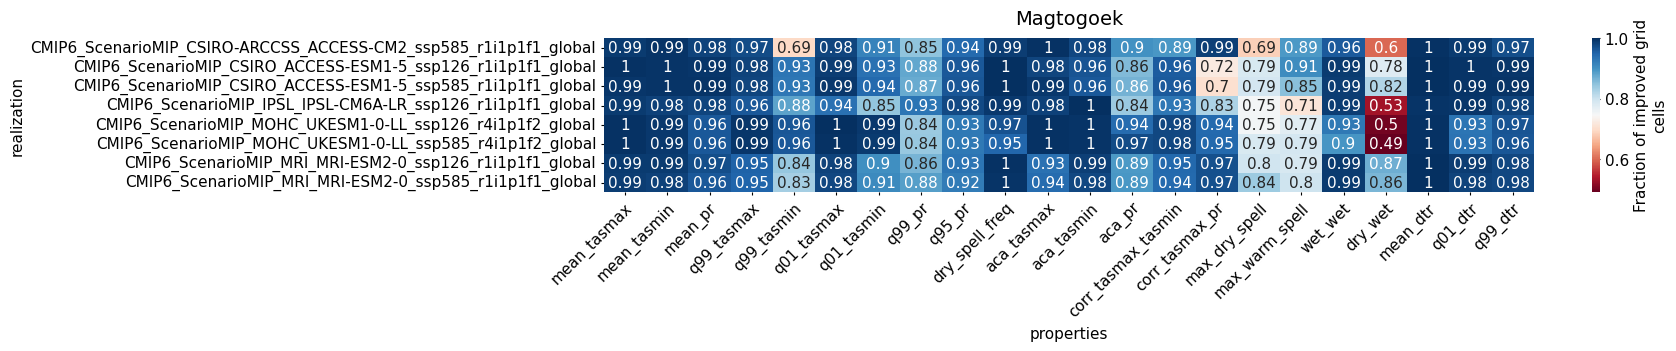

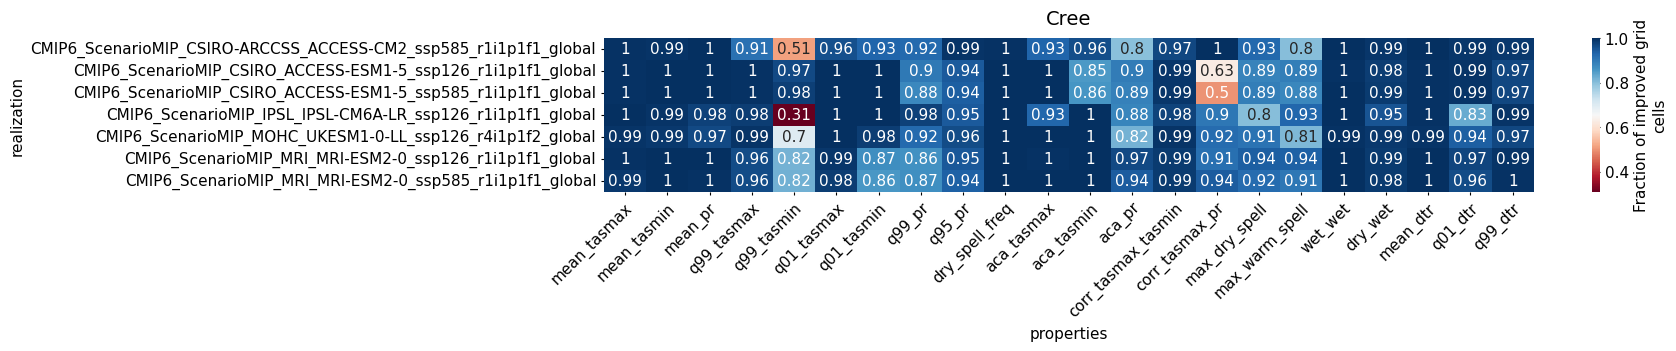

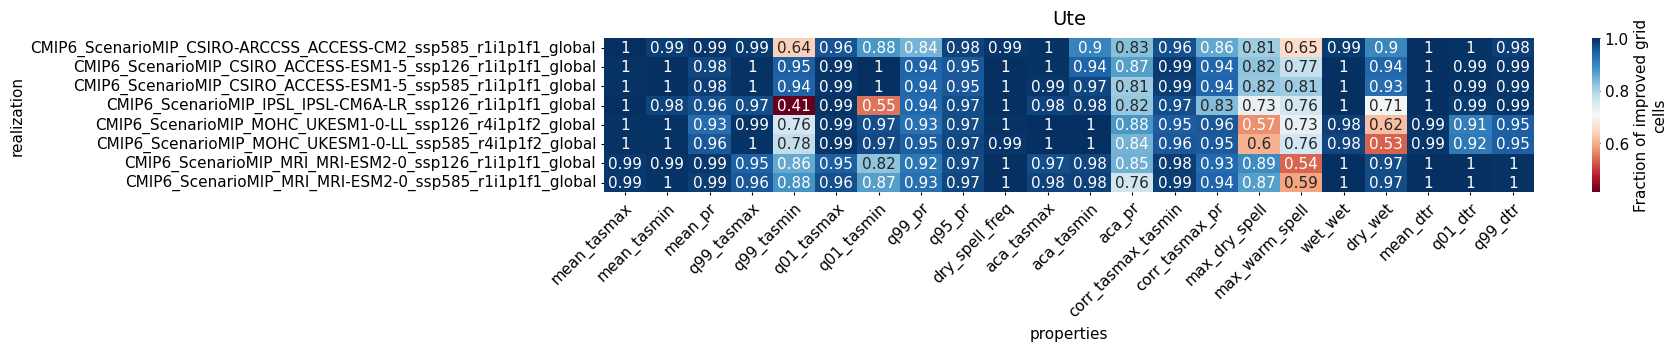

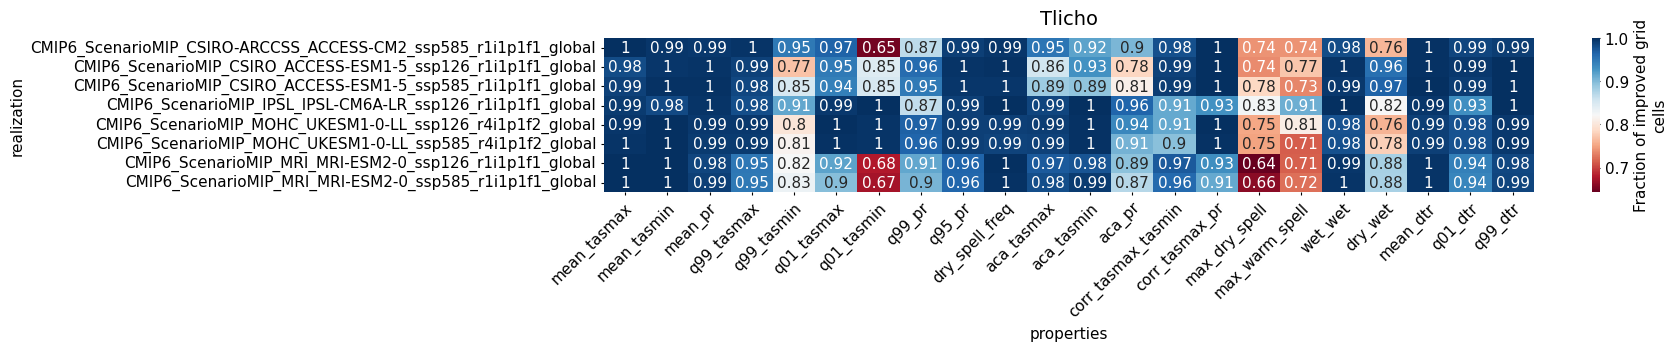

In [17]:


for r in ['Magtogoek','Cree','Ute','Tlicho']:

    imps=[]
    for f in np.sort(glob.glob(f"{CONFIG['paths']['final']}/diagnostics/CaSRv32/NAM-C3/{r}/CMIP6*/*imp.zarr.zip")):
        imp=xr.open_zarr(f, decode_timedelta=False)
        imp=imp.expand_dims(realization=[imp.attrs['cat:id']])
        
        imps.append(imp)

    ds_imp= xr.concat(imps, dim='realization')
    # #ds_imp=ds_imp.sel(properties=["mean_tasmax","mean_tasmin","mean_pr","mean_dtr","mean_hurs","mean_hursTasmax","q01_tasmax","q01_tasmin","q01_dtr","q01_hurs","q01_hursTasmax","q99_tasmax","q99_tasmin","q95_pr","q99_pr","q99_dtr","q99_hurs","q99_hursTasmax","dry_spell_freq","aca_tasmax","aca_tasmin","aca_pr","aca_hurs","aca_hursTasmax","corr_tasmax_tasmin","corr_tasmax_pr","corr_tasmax_hurs","corr_tasmax_hursTasmax","corr_pr_hurs","max_dry_spell","max_warm_spell","wet_wet","dry_wet",])
    ds_imp=ds_imp.drop_vars('rotated_pole')
    
    ax=fg.heatmap(ds_imp,plot_kw={'annot':True, }, fig_kw={'figsize':(15,2)})
    ax.set_title(r)

    # diff= ds_imp.sel(realization='DQM') - ds_imp.sel(realization='MBCn')
    # diff=diff.expand_dims(realization=['DQM-MBCn'])
    # vmin=-0.05
    # vmax=0.05
    #ax=fg.heatmap(diff,plot_kw={'annot':True, 'annot_kws':{"rotation": 90}, 'vmin':vmin,'vmax':vmax},cmap="Spectral", fig_kw={'figsize':(15,1)})
    #ax.figure.axes[1].set_yticks([vmin,vmax], labels=["MBCn", "DQM"])
    #ax.set_title(r)

# plot 1 day

/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.


KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x14c1c2c95260> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

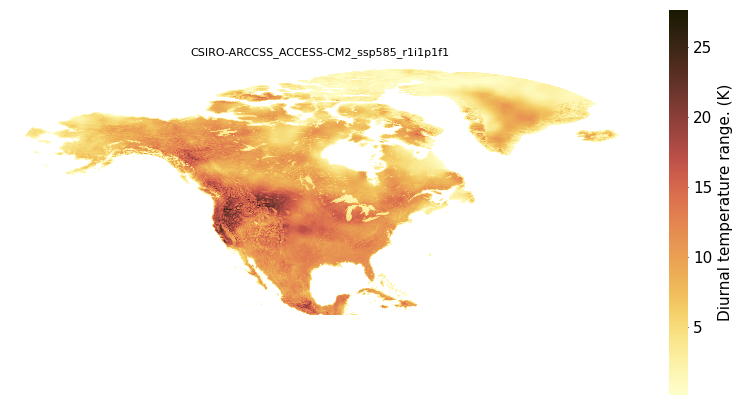

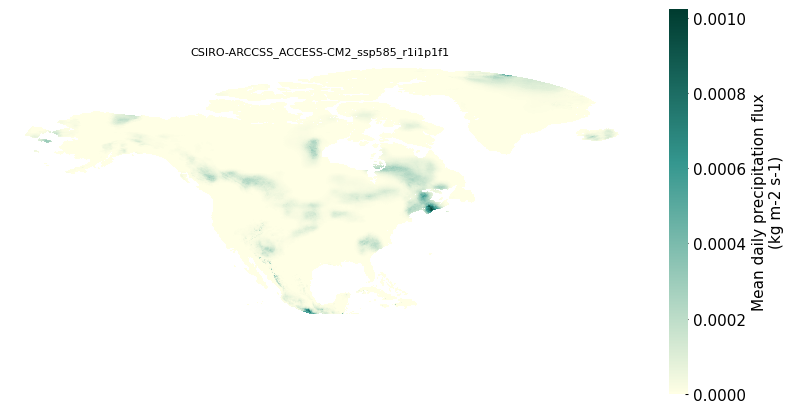

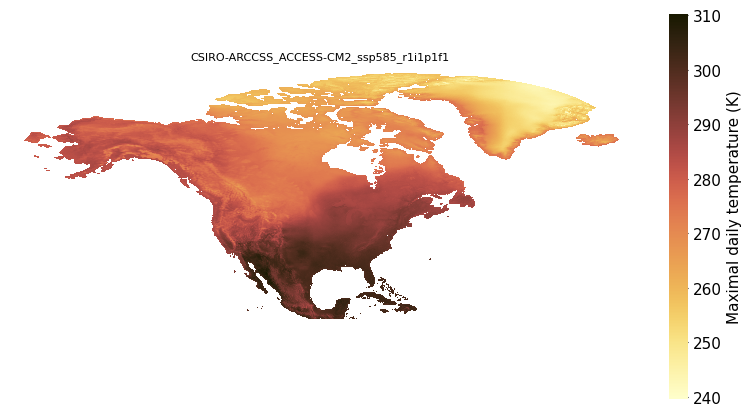

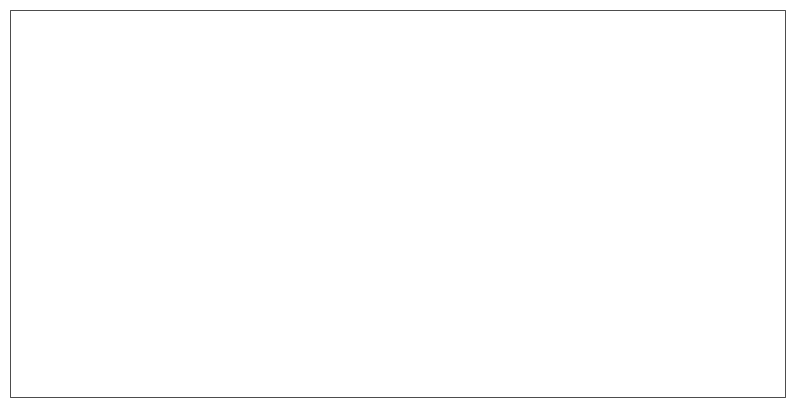

In [37]:
time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
for f in np.sort(glob.glob(f"{CONFIG['paths']['final']}/staging/simulation/biasadjusted/ESPO6-post2100_v2.0/CMIP6/ScenarioMIP/NAM-C3/*/*/*/*/*/*/*")):
    ds=xr.open_zarr(f, decode_times=time_coder)
    ax=fg.gridmap(ds.isel(time=random.randint(0, 128115)),plot_kw={ "cbar_kwargs": {"shrink": 0.5,}},fig_kw={'figsize':(10,10)}  )
    ax.set_extent([-179.95, -10, 10, 83.4 ], crs=ccrs.PlateCarree())
    ax.set_title(ds.attrs['cat:id'].replace('CMIP6_ScenarioMIP_','').replace('_global',''), fontsize=8)
ds

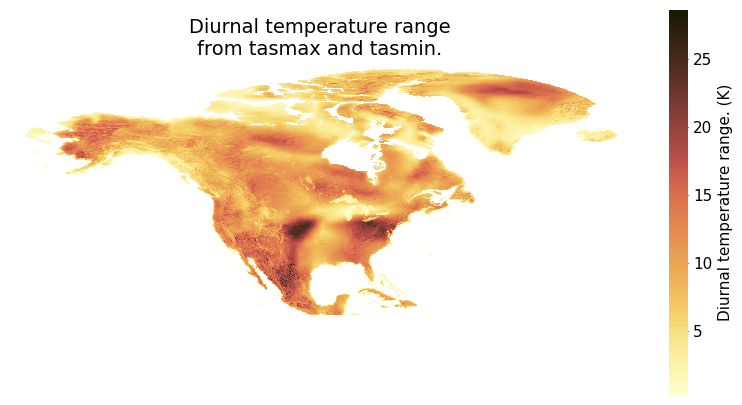

In [34]:
ax=fg.gridmap(ds.isel(time=random.randint(0, 128115)),plot_kw={ "cbar_kwargs": {"shrink": 0.5,}},fig_kw={'figsize':(10,10)}  )
ax.set_extent([-179.95, -10, 10, 83.4 ], crs=ccrs.PlateCarree())

In [30]:
ds.lat.min().values

array(9.279881, dtype=float32)